In [12]:
import pandas as pd
import numpy as np

#data visualization
import matplotlib.pyplot as plt
import matplotlib.cm as cm 
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns 
import shap

#sklearn
from sklearn.cluster import KMeans
from sklearn.preprocessing import PowerTransformer, OrdinalEncoder,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, silhouette_samples, accuracy_score, classification_report
from sklearn.compose import ColumnTransformer

from pyod.models.ecod import ECOD
from yellowbrick.cluster import KElbowVisualizer

#import lightgbm as lgb
import prince




In [3]:
df=pd.read_csv('Data/train.csv', sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [7]:
df=df.iloc[:,0:8]
df.head(5)

,age,job,marital,education,default,balance,housing,loan
0,58,management,married,tertiary,no,2143,yes,no
1,44,technician,single,secondary,no,29,yes,no
2,33,entrepreneur,married,secondary,no,2,yes,yes
3,47,blue-collar,married,unknown,no,1506,yes,no
4,33,unknown,single,unknown,no,1,no,no


In [11]:
#preprocessing part 
categorical_transformer_onehot=Pipeline(
    steps=[
        ('encoder',OneHotEncoder(handle_unknown='ignore',drop='first',sparse_output=False))])

categorical_transformer_ordinal=Pipeline(
    steps=[
        ("encoder",OrdinalEncoder())
    ])
num=Pipeline(
    steps=[('encoder' ,PowerTransformer())]
    )

In [16]:
preprocessor=ColumnTransformer(
    transformers=[
        ('Cat_onehot',categorical_transformer_onehot,['default','housing','loan','job','marital']),
        ('cat_ordinal',categorical_transformer_ordinal,['education']),
        ('num',num,['age','balance'])
    ]
)

In [17]:
pipeline=Pipeline(
    steps=[("preprocessor",preprocessor)]
)

pipe_fit=pipeline.fit(df)

In [18]:
data=pd.DataFrame(pipe_fit.transform(df),columns=pipe_fit.get_feature_names_out().tolist())

In [19]:
print(data.columns.tolist())

['Cat_onehot__default_yes', 'Cat_onehot__housing_yes', 'Cat_onehot__loan_yes', 'Cat_onehot__job_blue-collar', 'Cat_onehot__job_entrepreneur', 'Cat_onehot__job_housemaid', 'Cat_onehot__job_management', 'Cat_onehot__job_retired', 'Cat_onehot__job_self-employed', 'Cat_onehot__job_services', 'Cat_onehot__job_student', 'Cat_onehot__job_technician', 'Cat_onehot__job_unemployed', 'Cat_onehot__job_unknown', 'Cat_onehot__marital_married', 'Cat_onehot__marital_single', 'cat_ordinal__education', 'num__age', 'num__balance']


In [21]:
data

,Cat_onehot__default_yes,Cat_onehot__housing_yes,Cat_onehot__loan_yes,Cat_onehot__job_blue-collar,Cat_onehot__job_entrepreneur,Cat_onehot__job_housemaid,Cat_onehot__job_management,Cat_onehot__job_retired,Cat_onehot__job_self-employed,Cat_onehot__job_services,Cat_onehot__job_student,Cat_onehot__job_technician,Cat_onehot__job_unemployed,Cat_onehot__job_unknown,Cat_onehot__marital_married,Cat_onehot__marital_single,cat_ordinal__education,num__age,num__balance
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,1.473637,0.414773
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.429379,-0.410774
2,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,-0.709873,-0.431122
3,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,0.683128,0.197685
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,3.0,-0.709873,-0.432119
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.993503,-0.052398
45207,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.207438,0.275122
45208,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,2.257237,1.495765
45209,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.409327,-0.114235


**Outlier**
It is crucial that there are as few outliers in our data as Kmeans is very sensitive to this. We can apply the typical method of choosing outliers using the z score, but in this  I will show you a much more advanced and cool method.

we will use the Python Outlier Detection (PyOD) library. This library is focused on detecting outliers for different cases. To be more specific we will use the ECOD method (“empirical cumulative distribution functions for outlier detection”).

In [22]:
clf=ECOD()
clf.fit(data)
outliers=clf.predict(data)

data['outliers']=outliers

#data without outliers
data_no_outliers=data[data["outliers"]==0]
data_no_outliers = data_no_outliers.drop(["outliers"], axis = 1)

# Data with Outliers
data_with_outliers = data.copy()
data_with_outliers = data_with_outliers.drop(["outliers"], axis = 1)

print(data_no_outliers.shape) 
print(data_with_outliers.shape) 


(40690, 19)
(45211, 19)


**Modeling**

One of the disadvantages of using the Kmeans algorithm is that you must choose the number of clusters you want to use. In this case, in order to obtain that data, we will use Elbow Method. It consists of calculating the distortion that exists between the points of a cluster and its centroid. The objective is clear, to obtain the least possible distortion. 

/Users/suryasadasivam/DataScience /project/Customer_segmentation/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/Users/suryasadasivam/DataScience /project/Customer_segmentation/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

overflow encountered in matmul

/Users/suryasadasivam/DataScience /project/Customer_segmentation/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

invalid value encountered in matmul

/Users/suryasadasivam/DataScience /project/Customer_segmentation/venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning:

divide by zero encountered in matmul

/Users/suryasadasivam/DataScience /project/Customer_segmentation/venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning:

overflow encountered in matmul

/Users/suryasadasivam/DataScience /project/Customer_segmentation/venv/lib/python3.11/site

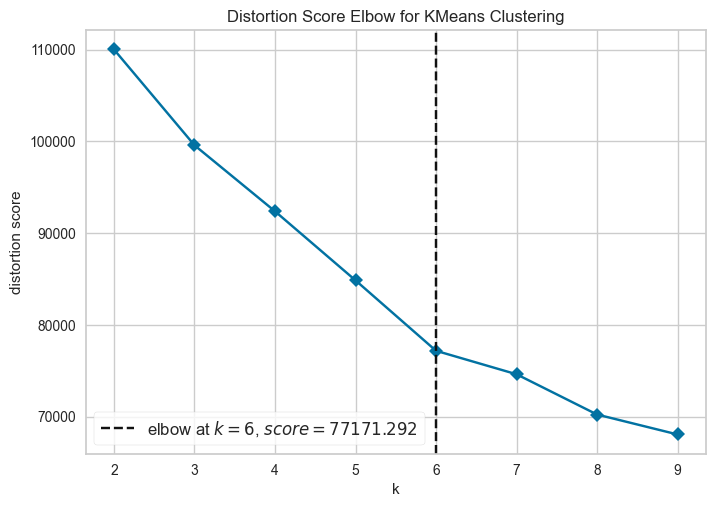

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [24]:

# Instantiate the clustering model and visualizer
km = KMeans(init="k-means++", random_state=0, n_init="auto")
visualizer = KElbowVisualizer(km, k=(2,10),timings=False)
 
visualizer.fit(data_no_outliers)        # Fit the data to the visualizer
visualizer.show()   



In [25]:
def make_Silhouette_plot(X, n_clusters):
    plt.xlim([-0.1, 1])
    plt.ylim([0, len(X) + (n_clusters + 1) * 10])
    clusterer = KMeans(n_clusters=n_clusters, max_iter = 1000, n_init = 10, init = 'k-means++', random_state=10)
    cluster_labels = clusterer.fit_predict(X)
    silhouette_avg = silhouette_score(X, cluster_labels)
    print(
        "For n_clusters =", n_clusters,
        "The average silhouette_score is :", silhouette_avg,
    )
# Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels)
    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        color = cm.nipy_spectral(float(i) / n_clusters)
        plt.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )
        plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10
        plt.title(f"The Silhouette Plot for n_cluster = {n_clusters}", fontsize=26)
        plt.xlabel("The silhouette coefficient values", fontsize=24)
        plt.ylabel("Cluster label", fontsize=24)
        plt.axvline(x=silhouette_avg, color="red", linestyle="--")
        plt.yticks([])  
        plt.xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])


    
range_n_clusters = list(range(2,10))

for n_clusters in range_n_clusters:
    print(f"N cluster: {n_clusters}")
    make_Silhouette_plot(data_no_outliers, n_clusters)   
    plt.savefig('Silhouette_plot_{}.png'.format(n_clusters))
    plt.close()

N cluster: 2


/Users/suryasadasivam/DataScience /project/Customer_segmentation/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/Users/suryasadasivam/DataScience /project/Customer_segmentation/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

overflow encountered in matmul

/Users/suryasadasivam/DataScience /project/Customer_segmentation/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

invalid value encountered in matmul

/Users/suryasadasivam/DataScience /project/Customer_segmentation/venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning:

divide by zero encountered in matmul

/Users/suryasadasivam/DataScience /project/Customer_segmentation/venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning:

overflow encountered in matmul

/Users/suryasadasivam/DataScience /project/Customer_segmentation/venv/lib/python3.11/site

For n_clusters = 2 The average silhouette_score is : 0.18111287366156348


/Users/suryasadasivam/DataScience /project/Customer_segmentation/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/Users/suryasadasivam/DataScience /project/Customer_segmentation/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

overflow encountered in matmul

/Users/suryasadasivam/DataScience /project/Customer_segmentation/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

invalid value encountered in matmul

/Users/suryasadasivam/DataScience /project/Customer_segmentation/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/Users/suryasadasivam/DataScience /project/Customer_segmentation/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

overflow encountered in matmul

/Users/suryasadasivam/DataScience /project/Customer_segmentation/venv/lib/python3.11/site-pac

N cluster: 3


...

/Users/suryasadasivam/DataScience /project/Customer_segmentation/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/Users/suryasadasivam/DataScience /project/Customer_segmentation/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

overflow encountered in matmul

/Users/suryasadasivam/DataScience /project/Customer_segmentation/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

invalid value encountered in matmul

/Users/suryasadasivam/DataScience /project/Customer_segmentation/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/Users/suryasadasivam/DataScience /project/Customer_segmentation/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

overflow encountered in matmul

/Users/suryasadasivam/DataScience /project/Customer_segmentation/venv/lib/python3.11/site-pac

N cluster: 9


/Users/suryasadasivam/DataScience /project/Customer_segmentation/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/Users/suryasadasivam/DataScience /project/Customer_segmentation/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

overflow encountered in matmul

/Users/suryasadasivam/DataScience /project/Customer_segmentation/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

invalid value encountered in matmul

/Users/suryasadasivam/DataScience /project/Customer_segmentation/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/Users/suryasadasivam/DataScience /project/Customer_segmentation/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

overflow encountered in matmul

/Users/suryasadasivam/DataScience /project/Customer_segmentation/venv/lib/python3.11/site-pac

For n_clusters = 9 The average silhouette_score is : 0.14842917303539022


/Users/suryasadasivam/DataScience /project/Customer_segmentation/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/Users/suryasadasivam/DataScience /project/Customer_segmentation/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

overflow encountered in matmul

/Users/suryasadasivam/DataScience /project/Customer_segmentation/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

invalid value encountered in matmul

/Users/suryasadasivam/DataScience /project/Customer_segmentation/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/Users/suryasadasivam/DataScience /project/Customer_segmentation/venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

overflow encountered in matmul

/Users/suryasadasivam/DataScience /project/Customer_segmentation/venv/lib/python3.11/site-pac

In [26]:
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)


N cluster: 2
N cluster: 3
N cluster: 4
N cluster: 5
N cluster: 6
N cluster: 7
N cluster: 8
N cluster: 9


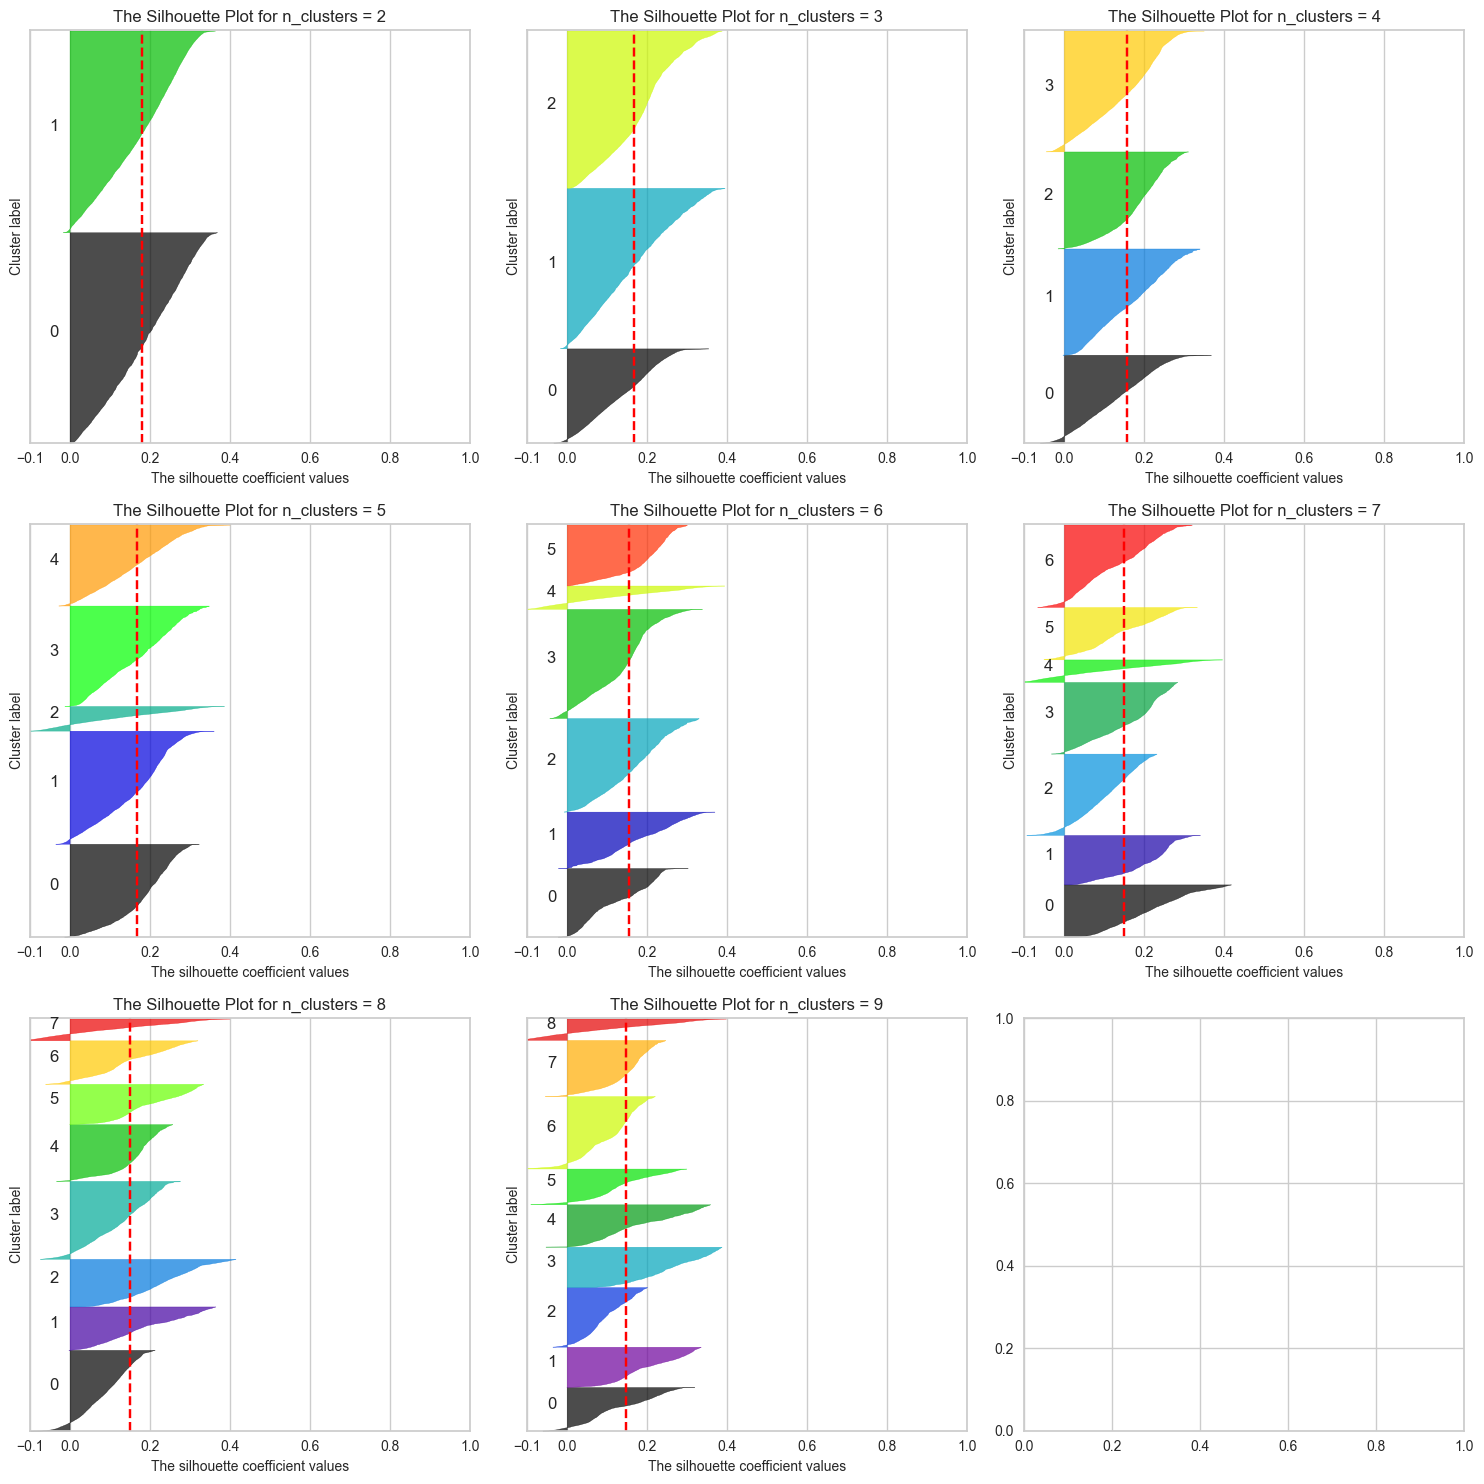

In [28]:
def make_Silhouette_plot(X, n_clusters, ax):
    ax.set_xlim([-0.1, 1])
    ax.set_ylim([0, len(X) + (n_clusters + 1) * 10])
    clusterer = KMeans(n_clusters=n_clusters, max_iter=1000, n_init=10, init='k-means++', random_state=10)
    cluster_labels = clusterer.fit_predict(X)
    silhouette_avg = silhouette_score(X, cluster_labels)
    ax.set_title(f"The Silhouette Plot for n_clusters = {n_clusters}", fontsize=12)
    ax.set_xlabel("The silhouette coefficient values", fontsize=10)
    ax.set_ylabel("Cluster label", fontsize=10)

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels)
    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        color = cm.nipy_spectral(float(i) / n_clusters)
        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax.set_yticks([])  
    ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])


# Create a subplot grid
n_rows = 3  # You can adjust the number of rows as needed
n_cols = 3  # Adjust the number of columns as well
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 15))

# Flatten the axes array for easy indexing
axes = axes.flatten()

range_n_clusters = list(range(2, 10))

# Loop through clusters and plot each on a different subplot
for i, n_clusters in enumerate(range_n_clusters):
    print(f"N cluster: {n_clusters}")
    make_Silhouette_plot(data_no_outliers, n_clusters, axes[i])

# Adjust layout and display the plot
plt.tight_layout()
plt.show()
